<a href="https://colab.research.google.com/github/goitstudent123/DL4CV-NLP/blob/main/dz_topic_12_HAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install datasets sentencepiece spacy matplotlib pandas numpy

In [2]:
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if torch.cuda.is_available():
    print("gpu_name:", torch.cuda.get_device_name(0))
    print("gpu_count:", torch.cuda.device_count())
else:
    print("gpu_name: CPU only")

LANG_PAIR = "cs-en"
SRC_LANG = "cs"
TGT_LANG = "en"

print("lang_pair:", LANG_PAIR)
print("src_lang:", SRC_LANG)
print("tgt_lang:", TGT_LANG)

device: cuda
gpu_name: NVIDIA RTX PRO 6000 Blackwell Server Edition
gpu_count: 1
lang_pair: cs-en
src_lang: cs
tgt_lang: en


In [3]:
dataset = load_dataset("Helsinki-NLP/europarl", LANG_PAIR)

print(dataset)
for split_name in dataset.keys():
    print(split_name, len(dataset[split_name]))
    print(dataset[split_name].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

cs-en/train-00000-of-00001.parquet:   0%|          | 0.00/114M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/647095 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 647095
    })
})
train 647095
['translation']


base_split: train
rows: 647095
columns: ['translation']

first_3_examples:
[0]
SRC: Následný postup na základě usnesení Parlamentu: viz zápis
TGT: Action taken on Parliament's resolutions: see Minutes

[1]
SRC: Předložení dokumentů: viz zápis
TGT: Documents received: see Minutes

[2]
SRC: Písemná prohlášení (článek 116 jednacího řádu): viz zápis
TGT: Written statements (Rule 116): see Minutes

analysis_sample_size: 50000

null_counts:
src_text    0
tgt_text    0
dtype: int64

empty_counts:
0 0

duplicate_pair_count: 1961

src_char_len_stats:
count    50000.000000
mean       131.138940
std         81.767145
min          2.000000
50%        118.000000
90%        236.000000
95%        282.000000
99%        384.010000
max       1453.000000
Name: src_char_len, dtype: float64

tgt_char_len_stats:
count    50000.000000
mean       140.189780
std         87.269124
min          2.000000
50%        126.000000
90%        253.000000
95%        301.000000
99%        412.010000
max       1352.000000


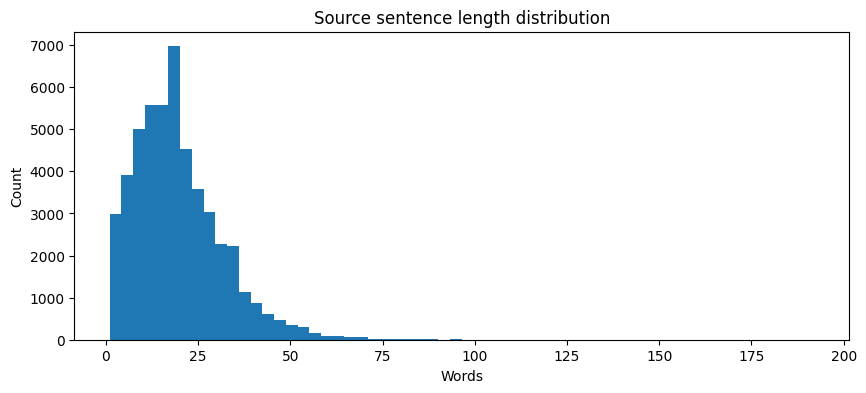

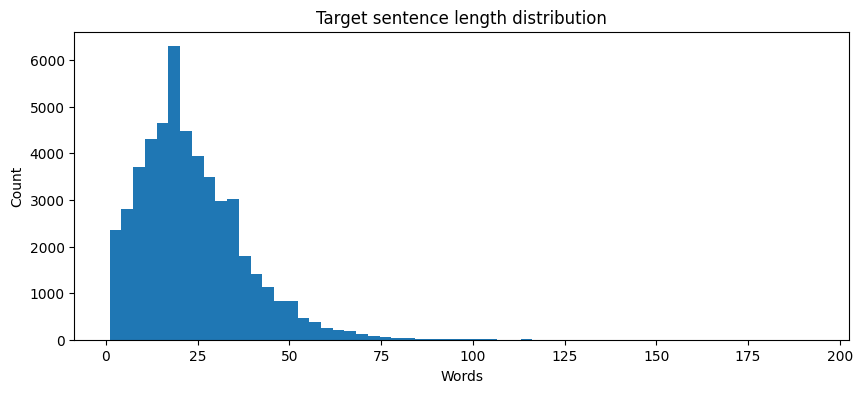

In [4]:
def extract_pair(example, src_lang, tgt_lang):
    if "translation" in example:
        src_text = example["translation"][src_lang]
        tgt_text = example["translation"][tgt_lang]
        return src_text, tgt_text

    if src_lang in example and tgt_lang in example:
        return example[src_lang], example[tgt_lang]

    raise ValueError(f"Cannot find parallel fields for {src_lang}-{tgt_lang}")


base_split_name = list(dataset.keys())[0]
base_ds = dataset[base_split_name]

print("base_split:", base_split_name)
print("rows:", len(base_ds))
print("columns:", base_ds.column_names)
print()

print("first_3_examples:")
for i in range(3):
    src_text, tgt_text = extract_pair(base_ds[i], SRC_LANG, TGT_LANG)
    print(f"[{i}]")
    print("SRC:", src_text)
    print("TGT:", tgt_text)
    print()

sample_size = min(50000, len(base_ds))
sample_ds = base_ds.select(range(sample_size))

pairs = [extract_pair(row, SRC_LANG, TGT_LANG) for row in sample_ds]
src_texts = [x[0] for x in pairs]
tgt_texts = [x[1] for x in pairs]

df = pd.DataFrame({
    "src_text": src_texts,
    "tgt_text": tgt_texts
})

df["src_char_len"] = df["src_text"].astype(str).str.len()
df["tgt_char_len"] = df["tgt_text"].astype(str).str.len()
df["src_word_len"] = df["src_text"].astype(str).str.split().str.len()
df["tgt_word_len"] = df["tgt_text"].astype(str).str.split().str.len()

print("analysis_sample_size:", sample_size)
print()

print("null_counts:")
print(df[["src_text", "tgt_text"]].isna().sum())
print()

print("empty_counts:")
print((df["src_text"].str.strip() == "").sum(), (df["tgt_text"].str.strip() == "").sum())
print()

print("duplicate_pair_count:", df.duplicated(subset=["src_text", "tgt_text"]).sum())
print()

print("src_char_len_stats:")
print(df["src_char_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()

print("tgt_char_len_stats:")
print(df["tgt_char_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()

print("src_word_len_stats:")
print(df["src_word_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()

print("tgt_word_len_stats:")
print(df["tgt_word_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()

print("top_5_longest_src_examples:")
longest_src_idx = df["src_word_len"].sort_values(ascending=False).head(5).index.tolist()
for idx in longest_src_idx:
    print(f"idx={idx}, src_words={df.loc[idx, 'src_word_len']}, tgt_words={df.loc[idx, 'tgt_word_len']}")
    print("SRC:", df.loc[idx, "src_text"][:500])
    print("TGT:", df.loc[idx, "tgt_text"][:500])
    print()

print("top_5_longest_tgt_examples:")
longest_tgt_idx = df["tgt_word_len"].sort_values(ascending=False).head(5).index.tolist()
for idx in longest_tgt_idx:
    print(f"idx={idx}, src_words={df.loc[idx, 'src_word_len']}, tgt_words={df.loc[idx, 'tgt_word_len']}")
    print("SRC:", df.loc[idx, "src_text"][:500])
    print("TGT:", df.loc[idx, "tgt_text"][:500])
    print()

plt.figure(figsize=(10, 4))
plt.hist(df["src_word_len"], bins=60)
plt.title("Source sentence length distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["tgt_word_len"], bins=60)
plt.title("Target sentence length distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [5]:
# Stage 3 - Prepare filtered splits
raw_ds = dataset["train"].shuffle(seed=SEED)

MAX_RAW_ROWS = 120000
MAX_SRC_TOKENS = 60
MAX_TGT_TOKENS = 70

def extract_pair(example, src_lang, tgt_lang):
    if "translation" in example:
        return example["translation"][src_lang], example["translation"][tgt_lang]
    return example[src_lang], example[tgt_lang]

pairs = [extract_pair(row, SRC_LANG, TGT_LANG) for row in raw_ds.select(range(MAX_RAW_ROWS))]

data_df = pd.DataFrame(pairs, columns=["src_text", "tgt_text"]).drop_duplicates().reset_index(drop=True)

data_df["src_len"] = data_df["src_text"].astype(str).str.strip().str.split().str.len()
data_df["tgt_len"] = data_df["tgt_text"].astype(str).str.strip().str.split().str.len()

data_df = data_df[
    (data_df["src_len"] >= 2) &
    (data_df["tgt_len"] >= 2) &
    (data_df["src_len"] <= MAX_SRC_TOKENS) &
    (data_df["tgt_len"] <= MAX_TGT_TOKENS)
].reset_index(drop=True)

data_df = data_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_total = len(data_df)
n_train = int(n_total * 0.8)
n_valid = int(n_total * 0.1)

train_df = data_df.iloc[:n_train].reset_index(drop=True)
valid_df = data_df.iloc[n_train:n_train + n_valid].reset_index(drop=True)
test_df = data_df.iloc[n_train + n_valid:].reset_index(drop=True)

print("MAX_RAW_ROWS:", MAX_RAW_ROWS)
print("filtered_total:", len(data_df))
print("train:", len(train_df))
print("valid:", len(valid_df))
print("test:", len(test_df))
print()

print(train_df[["src_len", "tgt_len"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()

print("sample_train_rows:")
print(train_df.head(3))

MAX_RAW_ROWS: 120000
filtered_total: 115982
train: 92785
valid: 11598
test: 11599

            src_len       tgt_len
count  92785.000000  92785.000000
mean      20.002156     24.043326
std       10.739033     12.703068
min        2.000000      2.000000
50%       18.000000     22.000000
90%       35.000000     42.000000
95%       41.000000     48.000000
99%       51.000000     61.000000
max       60.000000     70.000000

sample_train_rows:
                                            src_text  \
0  Chceme-li, aby naše rozvojová pomoc byla účinn...   
1  Jen se divím, proč se ho naši vedoucí představ...   
2  úřadující předseda Rady. - (PT) Paní předsedaj...   

                                            tgt_text  src_len  tgt_len  
0  If we want our development assistance to be ef...       15       22  
1  I just wonder why, over the past years, our EU...       15       17  
2  President-in-Office of the Council. - (PT) Mad...       42       54  


In [6]:
# Stage 3 - Build tokenizers
import spacy

spacy_cs = spacy.blank("cs")
spacy_en = spacy.blank("en")

def tokenize_cs(text):
    return [token.text.lower() for token in spacy_cs.tokenizer(text.strip()) if token.text.strip()]

def tokenize_en(text):
    return [token.text.lower() for token in spacy_en.tokenizer(text.strip()) if token.text.strip()]

sample_src = train_df.iloc[0]["src_text"]
sample_tgt = train_df.iloc[0]["tgt_text"]

print("sample_src:", sample_src)
print("tokenized_src:", tokenize_cs(sample_src)[:30])
print()
print("sample_tgt:", sample_tgt)
print("tokenized_tgt:", tokenize_en(sample_tgt)[:30])

sample_src: Chceme-li, aby naše rozvojová pomoc byla účinná, musíme se ujistit, že jí nepřekáží ostatní politiky.
tokenized_src: ['chceme', '-', 'li', ',', 'aby', 'naše', 'rozvojová', 'pomoc', 'byla', 'účinná', ',', 'musíme', 'se', 'ujistit', ',', 'že', 'jí', 'nepřekáží', 'ostatní', 'politiky', '.']

sample_tgt: If we want our development assistance to be effective, we need to make sure that it is not hampered by other policies.
tokenized_tgt: ['if', 'we', 'want', 'our', 'development', 'assistance', 'to', 'be', 'effective', ',', 'we', 'need', 'to', 'make', 'sure', 'that', 'it', 'is', 'not', 'hampered', 'by', 'other', 'policies', '.']


In [7]:
# Stage 3 - Build vocabularies
from collections import Counter

SPECIALS = ["<pad>", "<unk>", "<sos>", "<eos>"]
MIN_FREQ = 3

def build_vocab(texts, tokenizer, min_freq):
    counter = Counter()
    for text in texts:
        counter.update(tokenizer(text))
    tokens = sorted([token for token, freq in counter.items() if freq >= min_freq])
    itos = SPECIALS + tokens
    stoi = {token: idx for idx, token in enumerate(itos)}
    return stoi, itos, counter

src_stoi, src_itos, src_counter = build_vocab(train_df["src_text"], tokenize_cs, MIN_FREQ)
tgt_stoi, tgt_itos, tgt_counter = build_vocab(train_df["tgt_text"], tokenize_en, MIN_FREQ)

SRC_PAD_IDX = src_stoi["<pad>"]
SRC_UNK_IDX = src_stoi["<unk>"]
SRC_SOS_IDX = src_stoi["<sos>"]
SRC_EOS_IDX = src_stoi["<eos>"]

TGT_PAD_IDX = tgt_stoi["<pad>"]
TGT_UNK_IDX = tgt_stoi["<unk>"]
TGT_SOS_IDX = tgt_stoi["<sos>"]
TGT_EOS_IDX = tgt_stoi["<eos>"]

print("src_vocab_size:", len(src_itos))
print("tgt_vocab_size:", len(tgt_itos))
print("src_top_20:", src_counter.most_common(20))
print("tgt_top_20:", tgt_counter.most_common(20))

src_vocab_size: 31776
tgt_vocab_size: 14608
src_top_20: [(',', 155219), ('.', 94517), ('a', 68608), ('v', 41914), ('se', 32313), ('na', 28613), ('je', 27743), ('že', 26845), ('o', 18252), ('pro', 15784), ('to', 13297), ('s', 13255), ('k', 12000), ('-', 11623), ('z', 9378), ('aby', 9115), ('které', 9039), ('by', 8860), ('ve', 7935), ('za', 7633)]
tgt_top_20: [('the', 169007), (',', 117584), ('.', 91156), ('of', 80988), ('to', 74083), ('and', 66858), ('in', 55027), ('that', 38587), ('a', 37589), ('is', 36981), ('for', 27421), ('we', 25754), ('i', 24862), ('this', 24746), ('on', 22911), ('-', 20630), ('it', 20243), ('be', 18494), ('are', 16848), ('not', 16120)]


In [8]:
# Stage 3 - Numericalize data and create loaders
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

def tokens_to_ids(tokens, stoi, unk_idx):
    return [stoi.get(token, unk_idx) for token in tokens]

def encode_example(src_text, tgt_text):
    src_tokens = tokenize_cs(src_text)
    tgt_tokens = tokenize_en(tgt_text)

    if not (2 <= len(src_tokens) <= MAX_SRC_TOKENS and 2 <= len(tgt_tokens) <= MAX_TGT_TOKENS):
        return None

    src_ids = [SRC_SOS_IDX] + tokens_to_ids(src_tokens, src_stoi, SRC_UNK_IDX) + [SRC_EOS_IDX]
    tgt_ids = [TGT_SOS_IDX] + tokens_to_ids(tgt_tokens, tgt_stoi, TGT_UNK_IDX) + [TGT_EOS_IDX]

    return {
        "src_ids": src_ids,
        "tgt_ids": tgt_ids,
        "src_text": src_text,
        "tgt_text": tgt_text
    }

def encode_split(df):
    encoded = []
    for row in df.itertuples(index=False):
        item = encode_example(row.src_text, row.tgt_text)
        if item is not None:
            encoded.append(item)
    return encoded

train_data = encode_split(train_df)
valid_data = encode_split(valid_df)
test_data = encode_split(test_df)

class TranslationDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

def collate_fn(batch):
    src_batch = [torch.tensor(item["src_ids"], dtype=torch.long) for item in batch]
    tgt_batch = [torch.tensor(item["tgt_ids"], dtype=torch.long) for item in batch]

    src_lengths = torch.tensor([len(x) for x in src_batch], dtype=torch.long)

    src_padded = pad_sequence(src_batch, padding_value=SRC_PAD_IDX)
    tgt_padded = pad_sequence(tgt_batch, padding_value=TGT_PAD_IDX)

    return src_padded.to(device), src_lengths.to(device), tgt_padded.to(device)

BATCH_SIZE = 96

train_loader = DataLoader(
    TranslationDataset(train_data),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    TranslationDataset(valid_data),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    TranslationDataset(test_data),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

src_batch, src_lengths, tgt_batch = next(iter(train_loader))

print("encoded_train:", len(train_data))
print("encoded_valid:", len(valid_data))
print("encoded_test:", len(test_data))
print("src_batch_shape:", tuple(src_batch.shape))
print("src_lengths_shape:", tuple(src_lengths.shape))
print("tgt_batch_shape:", tuple(tgt_batch.shape))
print("first_src_lengths:", src_lengths[:10].tolist())

encoded_train: 91849
encoded_valid: 11463
encoded_test: 11495
src_batch_shape: (53, 96)
src_lengths_shape: (96,)
tgt_batch_shape: (57, 96)
first_src_lengths: [34, 11, 28, 17, 10, 20, 17, 14, 24, 36]


In [9]:
# Stage 4 - Define seq2seq with attention
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=SRC_PAD_IDX)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_embedded = pack_padded_sequence(embedded, src_lengths.cpu(), enforce_sorted=False)
        packed_outputs, hidden = self.rnn(packed_embedded)
        outputs, _ = pad_packed_sequence(packed_outputs)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2], hidden[-1]), dim=1)))
        return outputs, hidden


class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear(enc_hid_dim * 2 + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        attention = attention.masked_fill(mask == 0, -1e10)

        return torch.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=TGT_PAD_IDX)
        self.rnn = nn.GRU(enc_hid_dim * 2 + emb_dim, dec_hid_dim)
        self.fc_out = nn.Linear(enc_hid_dim * 2 + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, mask):
        input_token = input_token.unsqueeze(0)

        embedded = self.dropout(self.embedding(input_token))
        attn_weights = self.attention(hidden, encoder_outputs, mask)
        attn_weights = attn_weights.unsqueeze(1)

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(attn_weights, encoder_outputs)
        weighted = weighted.permute(1, 0, 2)

        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))

        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))

        return prediction, hidden.squeeze(0), attn_weights.squeeze(1)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.device = device

    def create_mask(self, src):
        return (src != self.src_pad_idx).permute(1, 0)

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[1]
        tgt_len = tgt.shape[0]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(tgt_len, batch_size, tgt_vocab_size, device=self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)
        input_token = tgt[0]
        mask = self.create_mask(src)

        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, mask)
            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = tgt[t] if teacher_force else top1

        return outputs

In [10]:
# Stage 5 - Define loss, optimizer and helpers
import time

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def epoch_time(start_time, end_time):
    elapsed = int(end_time - start_time)
    return elapsed // 60, elapsed % 60

def train_epoch(model, loader, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0.0

    for src, src_lengths, tgt in loader:
        optimizer.zero_grad()

        output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.5)
        output_dim = output.shape[-1]

        output = output[1:].reshape(-1, output_dim)
        tgt_gold = tgt[1:].reshape(-1)

        loss = criterion(output, tgt_gold)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0.0

    for src, src_lengths, tgt in loader:
        output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
        output_dim = output.shape[-1]

        output = output[1:].reshape(-1, output_dim)
        tgt_gold = tgt[1:].reshape(-1)

        loss = criterion(output, tgt_gold)
        epoch_loss += loss.item()

    return epoch_loss / len(loader)

@torch.no_grad()
def translate_sentence(model, sentence, max_len=80):
    model.eval()

    src_tokens = tokenize_cs(sentence)
    src_ids = [SRC_SOS_IDX] + tokens_to_ids(src_tokens, src_stoi, SRC_UNK_IDX) + [SRC_EOS_IDX]

    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)
    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long).to(device)

    encoder_outputs, hidden = model.encoder(src_tensor, src_lengths)
    mask = model.create_mask(src_tensor)

    input_token = torch.tensor([TGT_SOS_IDX], dtype=torch.long, device=device)

    generated_ids = []
    attentions = []

    for _ in range(max_len):
        output, hidden, attn = model.decoder(input_token, hidden, encoder_outputs, mask)
        pred_token = output.argmax(1).item()

        generated_ids.append(pred_token)
        attentions.append(attn.squeeze(0).detach().cpu())

        if pred_token == TGT_EOS_IDX:
            break

        input_token = torch.tensor([pred_token], dtype=torch.long, device=device)

    pred_tokens = []
    for idx in generated_ids:
        token = tgt_itos[idx]
        if token == "<eos>":
            break
        pred_tokens.append(token)

    attention_tensor = torch.stack(attentions) if attentions else torch.zeros(0, len(src_ids))
    src_labels = ["<sos>"] + src_tokens + ["<eos>"]

    return pred_tokens, attention_tensor, src_labels

In [11]:
# Stage 5 - Initialize model
INPUT_DIM = len(src_itos)
OUTPUT_DIM = len(tgt_itos)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 256
DEC_HID_DIM = 256
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

attention = Attention(ENC_HID_DIM, DEC_HID_DIM)
encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attention)

model = Seq2Seq(encoder, decoder, SRC_PAD_IDX, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

print("trainable_parameters:", count_parameters(model))
model

trainable_parameters: 28753424


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(31776, 256, padding_idx=0)
    (rnn): GRU(256, 256, bidirectional=True)
    (fc): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=768, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(14608, 256, padding_idx=0)
    (rnn): GRU(768, 256)
    (fc_out): Linear(in_features=1024, out_features=14608, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [12]:
# Stage 6 - Train model
N_EPOCHS = 5
CLIP = 1.0

train_losses = []
valid_losses = []

best_valid_loss = float("inf")
best_model_path = "best_seq2seq_attention.pt"

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate_epoch(model, valid_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), best_model_path)

    end_time = time.time()
    mins, secs = epoch_time(start_time, end_time)

    print(f"Epoch: {epoch + 1:02} | Time: {mins}m {secs}s")
    print(f"\tTrain Loss: {train_loss:.4f} | Train PPL: {math.exp(train_loss):.4f}")
    print(f"\tValid Loss: {valid_loss:.4f} | Valid PPL: {math.exp(valid_loss):.4f}")

model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss = evaluate_epoch(model, test_loader, criterion)

print()
print(f"Best Valid Loss: {best_valid_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test PPL: {math.exp(test_loss):.4f}")

Epoch: 01 | Time: 1m 43s
	Train Loss: 5.2581 | Train PPL: 192.1105
	Valid Loss: 5.2421 | Valid PPL: 189.0718
Epoch: 02 | Time: 1m 42s
	Train Loss: 4.4518 | Train PPL: 85.7800
	Valid Loss: 5.0454 | Valid PPL: 155.3042
Epoch: 03 | Time: 1m 41s
	Train Loss: 4.1439 | Train PPL: 63.0492
	Valid Loss: 4.9411 | Valid PPL: 139.9305
Epoch: 04 | Time: 1m 41s
	Train Loss: 3.9346 | Train PPL: 51.1432
	Valid Loss: 4.9049 | Valid PPL: 134.9472
Epoch: 05 | Time: 1m 40s
	Train Loss: 3.7884 | Train PPL: 44.1853
	Valid Loss: 4.8868 | Valid PPL: 132.5235

Best Valid Loss: 4.8868
Test Loss: 4.8720
Test PPL: 130.5791


In [16]:
# Stage 6 - Continue training model
ADDITIONAL_EPOCHS = 7
CLIP = 1.0

if "train_losses" not in globals():
    train_losses = []
if "valid_losses" not in globals():
    valid_losses = []

best_model_path = "best_seq2seq_attention.pt"
best_valid_loss = min(valid_losses) if len(valid_losses) > 0 else float("inf")

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

start_epoch = len(train_losses)

for epoch in range(ADDITIONAL_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate_epoch(model, valid_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    scheduler.step(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), best_model_path)

    end_time = time.time()
    mins, secs = epoch_time(start_time, end_time)

    current_epoch = start_epoch + epoch + 1
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch: {current_epoch:02} | Time: {mins}m {secs}s | LR: {current_lr:.6f}")
    print(f"\tTrain Loss: {train_loss:.4f} | Train PPL: {math.exp(train_loss):.4f}")
    print(f"\tValid Loss: {valid_loss:.4f} | Valid PPL: {math.exp(valid_loss):.4f}")

model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss = evaluate_epoch(model, test_loader, criterion)

print()
print(f"Best Valid Loss: {best_valid_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test PPL: {math.exp(test_loss):.4f}")

Epoch: 06 | Time: 1m 40s | LR: 0.000500
	Train Loss: 3.6268 | Train PPL: 37.5911
	Valid Loss: 4.8327 | Valid PPL: 125.5547
Epoch: 07 | Time: 1m 40s | LR: 0.000500
	Train Loss: 3.5303 | Train PPL: 34.1336
	Valid Loss: 4.8519 | Valid PPL: 127.9839
Epoch: 08 | Time: 1m 40s | LR: 0.000250
	Train Loss: 3.4581 | Train PPL: 31.7557
	Valid Loss: 4.8509 | Valid PPL: 127.8558
Epoch: 09 | Time: 1m 40s | LR: 0.000250
	Train Loss: 3.3628 | Train PPL: 28.8686
	Valid Loss: 4.8613 | Valid PPL: 129.1930
Epoch: 10 | Time: 1m 40s | LR: 0.000125
	Train Loss: 3.3218 | Train PPL: 27.7113
	Valid Loss: 4.8484 | Valid PPL: 127.5405
Epoch: 11 | Time: 1m 40s | LR: 0.000125
	Train Loss: 3.2787 | Train PPL: 26.5406
	Valid Loss: 4.8229 | Valid PPL: 124.3221
Epoch: 12 | Time: 1m 40s | LR: 0.000125
	Train Loss: 3.2591 | Train PPL: 26.0256
	Valid Loss: 4.8400 | Valid PPL: 126.4745

Best Valid Loss: 4.8229
Test Loss: 4.8009
Test PPL: 121.6146


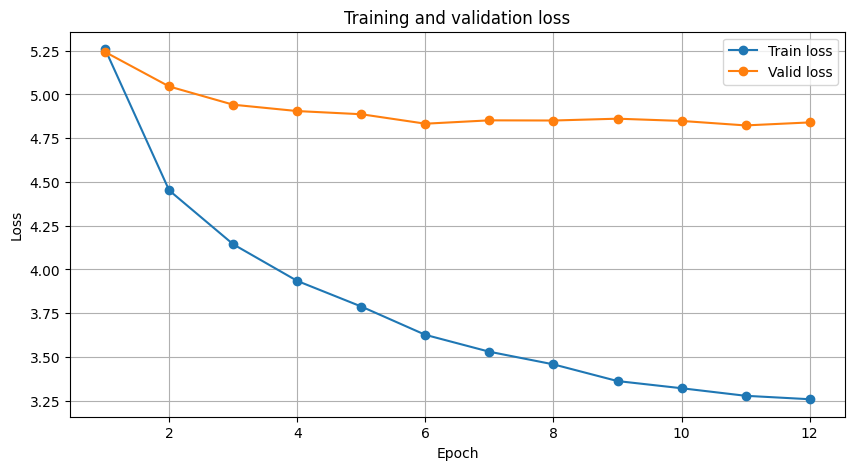

In [17]:
# Stage 7 - Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="Train loss")
plt.plot(range(1, len(valid_losses) + 1), valid_losses, marker="o", label="Valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Stage 9 - Show translation examples
example_indices = [0, 1, 2, 3, 4]

for idx in example_indices:
    src_text = test_df.iloc[idx]["src_text"]
    tgt_text = test_df.iloc[idx]["tgt_text"]

    pred_tokens, _, _ = translate_sentence(model, src_text)
    pred_text = " ".join(pred_tokens)

    print(f"Example {idx}")
    print("SRC:", src_text)
    print("REF:", tgt_text)
    print("PRD:", pred_text)
    print()

Example 0
SRC: Pane předsedo, pane úřadující předsedo Rady, pane komisaři, členské státy zavádějí mnohé evropské nástroje zaměřené na boj proti terorismu.
REF: Mr President, President-in-Office of the Council, Commissioner, many European instruments to fight terrorism have been introduced by Member States.
PRD: mr president , president - in - office of the council , commissioner , member states have a series of european instruments instruments aimed at combating terrorism .

Example 1
SRC: Někdo si tu stěžoval, že stoupá spotřeba masa.
REF: There have been complaints that meat consumption is on the increase.
PRD: someone are complained that meat consumption meat meat meat . meat .

Example 2
SRC: Nutností je účinná politika EU zaměřená na posílení křehké demokracie a zajištění skutečné svobody shromažďování, médií a slova.
REF: There needs to be an effective EU policy for strengthening the fragile democracy and ensuring genuine freedom of assembly, the media and speech.
PRD: the eu is 

Attention example 0
SRC: Pane předsedo, pane úřadující předsedo Rady, pane komisaři, členské státy zavádějí mnohé evropské nástroje zaměřené na boj proti terorismu.
REF: Mr President, President-in-Office of the Council, Commissioner, many European instruments to fight terrorism have been introduced by Member States.
PRD: mr president , president - in - office of the council , commissioner , member states have a series of european instruments instruments aimed at combating terrorism .



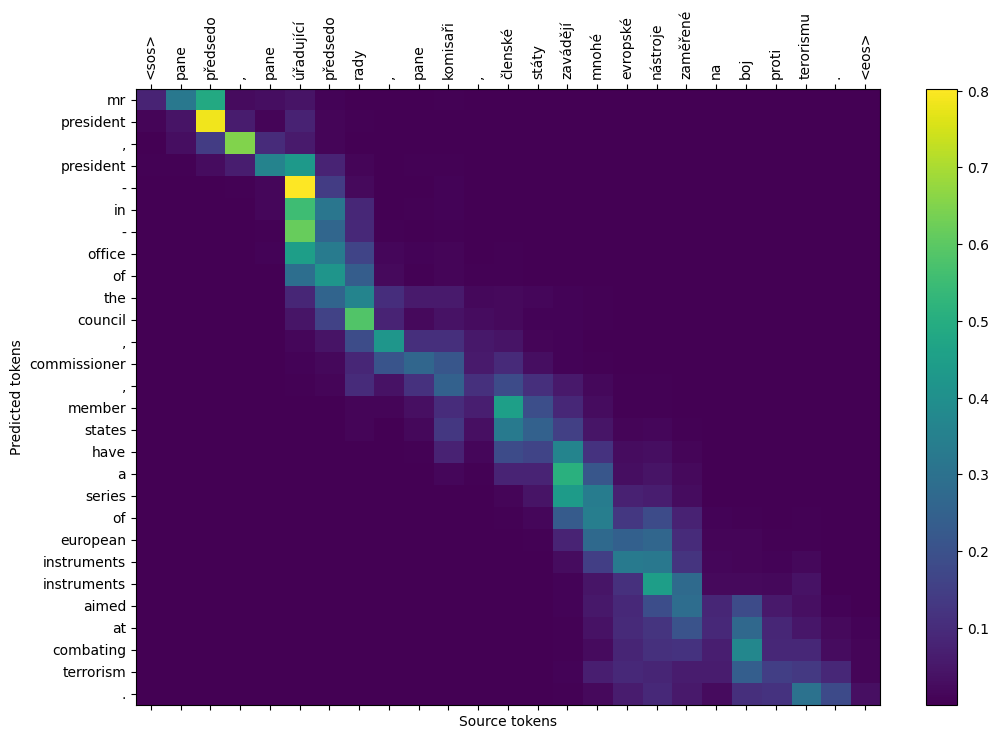

Attention example 1
SRC: Někdo si tu stěžoval, že stoupá spotřeba masa.
REF: There have been complaints that meat consumption is on the increase.
PRD: someone are complained that meat consumption meat meat meat . meat .



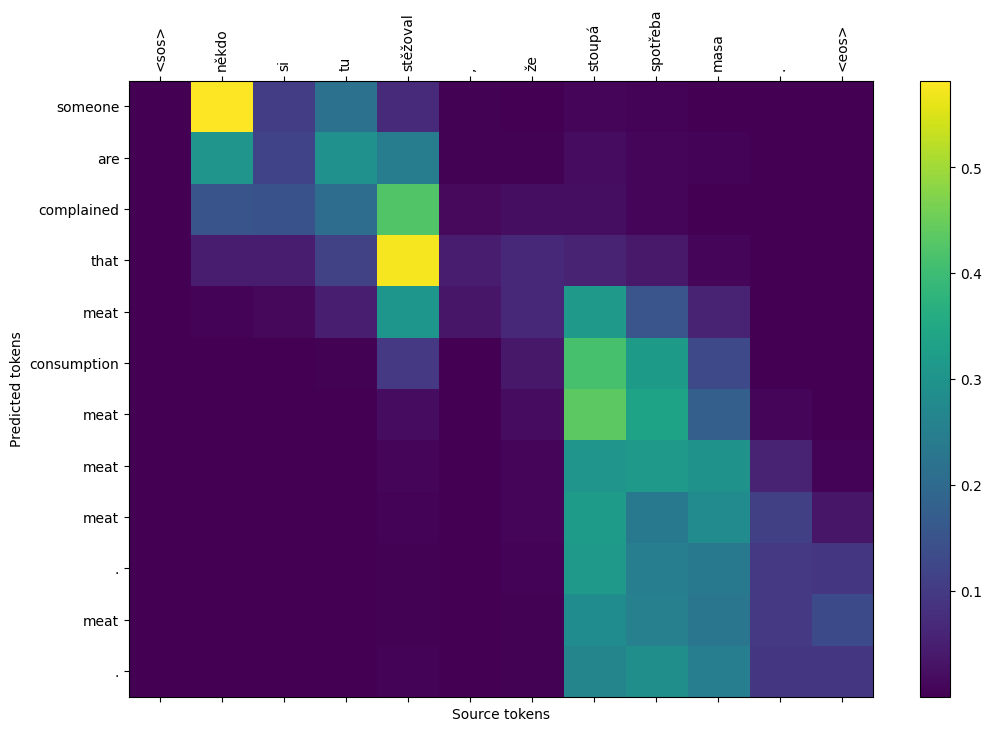

Attention example 2
SRC: Nutností je účinná politika EU zaměřená na posílení křehké demokracie a zajištění skutečné svobody shromažďování, médií a slova.
REF: There needs to be an effective EU policy for strengthening the fragile democracy and ensuring genuine freedom of assembly, the media and speech.
PRD: the eu is effective effective policy policy aimed at strengthening democracy strengthening ensuring democracy and ensuring freedom of freedom of media media media media media and media .



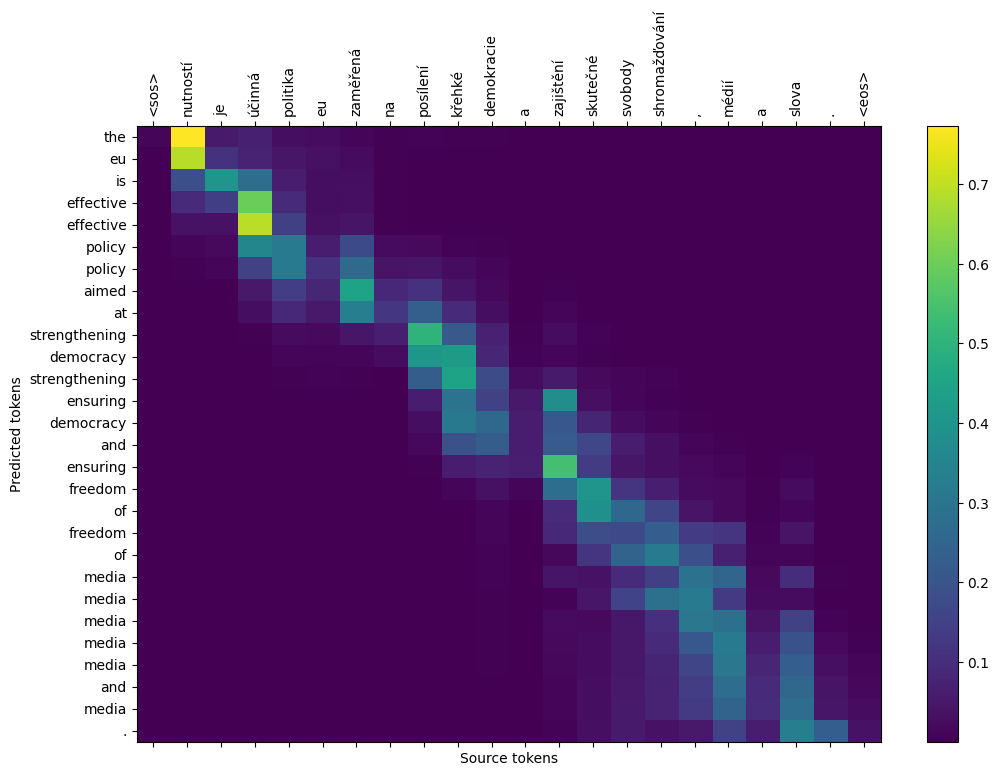

In [19]:
# Stage 7 - Visualize attention
def plot_attention(src_labels, pred_tokens, attention_tensor, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(attention_tensor.numpy(), aspect="auto")
    fig.colorbar(cax)

    ax.set_xticks(range(len(src_labels)))
    ax.set_xticklabels(src_labels, rotation=90)

    y_labels = pred_tokens if pred_tokens else ["<empty>"]
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)

    ax.set_xlabel("Source tokens")
    ax.set_ylabel("Predicted tokens")
    plt.show()

attention_example_indices = [0, 1, 2]

for idx in attention_example_indices:
    src_text = test_df.iloc[idx]["src_text"]
    tgt_text = test_df.iloc[idx]["tgt_text"]

    pred_tokens, attention_tensor, src_labels = translate_sentence(model, src_text)

    print(f"Attention example {idx}")
    print("SRC:", src_text)
    print("REF:", tgt_text)
    print("PRD:", " ".join(pred_tokens))
    print()

    if len(pred_tokens) > 0 and attention_tensor.shape[0] > 0:
        plot_attention(src_labels, pred_tokens, attention_tensor[:len(pred_tokens)])

# Висновки

## Аналіз результатів навчання

Для задачі машинного перекладу було обрано мовну пару [чеська → англійська](https://huggingface.co/datasets/Helsinki-NLP/europarl/tree/main/cs-en) з набору даних [Helsinki-NLP/europarl](https://huggingface.co/datasets/Helsinki-NLP/europarl).
Після початкового аналізу датасету було встановлено, що основна частина речень має помірну довжину, але присутній довгий хвіст дуже довгих прикладів. Також у вибірці виявлено невелику кількість дублікатів. Тому перед навчанням було виконано:

* видалення дублікатів,
* фільтрацію занадто довгих речень,
* розбиття даних на train / validation / test,
* токенізацію тексту,
* побудову словників для обох мов.

Для моделі було використано архітектуру Seq2Seq з GRU та механізмом уваги.
Енкодер обробляє вхідне речення чеською мовою, декодер генерує переклад англійською, а attention допомагає декодеру фокусуватися на релевантних токенах вхідної послідовності.

## Аналіз функції втрат

Під час навчання значення функції втрат на тренувальному наборі стабільно зменшувалося:

* на початку: Train Loss = 5.2581
* після навчання: Train Loss = 3.2591

Втрати на валідаційному наборі також зменшувалися, хоча значно повільніше:

* на початку: Valid Loss = 5.2421
* найкраще значення: Valid Loss = 4.8229

На тестовому наборі модель показала:

* Test Loss = 4.8009
* Test PPL = 121.6146

Графік показує, що модель дійсно навчається: train loss впевнено спадає, а validation loss поступово покращується. Водночас між train loss і validation loss зберігається помітний розрив. Це означає, що модель добре підлаштовується під тренувальні дані, але її здатність до узагальнення ще обмежена. Тобто модель уже вивчила базові закономірності перекладу, проте ще не досягла високої якості на unseen data.

## Аналіз прикладів перекладу

У прикладах перекладу видно, що модель уже вміє:

* правильно розпізнавати загальний зміст речення,
* перекладати частину ключових слів,
* частково відтворювати синтаксичну структуру англійського речення.

Наприклад, у першому реченні модель коректно відтворила звертання, згадку про Council, Commissioner, Member States, European instruments та terrorism. Це свідчить, що модель уже навчилась захоплювати головні змістові опори речення.

Водночас у перекладах залишаються типові проблеми:

* повторення слів (meat meat meat, media media media, 2008 2008),
* втрата частини змісту,
* спрощення або викривлення граматичної структури,
* гірша якість на довших реченнях.

Отже, модель уже формує змістовно близький переклад, але ще не забезпечує достатньо стабільне та граматично коректне декодування.

## Аналіз механізму уваги

Механізм уваги використовується для того, щоб на кожному кроці генерації перекладу декодер міг звертати більше уваги на ті частини вхідного речення, які найбільш важливі саме для поточного слова виходу.

За візуалізаціями attention можна зробити такі висновки:

* для коротших і простіших речень увага зазвичай концентрується більш локально;
* для довших речень розподіл уваги стає менш чітким;
* у складних прикладах модель іноді втрачає точне вирівнювання між словами джерела і перекладу, що призводить до повторів або пропуску змісту.

Таким чином, attention дійсно допомагає моделі знаходити зв’язок між вхідною та вихідною послідовностями, але сам по собі не усуває всіх проблем декодування. Якість уваги сильно залежить від розміру моделі, кількості епох і загальної якості навчання.

## Сильні сторони моделі

* модель коректно реалізована і навчається без помилок;
* train і validation loss знижуються;
* attention інтегровано та візуалізовано;
* модель уже може передавати загальний зміст багатьох речень;
* короткі та шаблонні речення перекладаються помітно краще, ніж на початку.

## Слабкі сторони моделі

* якість перекладу ще недостатньо висока для складних речень;
* спостерігаються повтори токенів;
* validation loss залишається досить високим;
* модель гірше працює на довгих реченнях із багатьма залежностями;
* word-level підхід обмежує якість узагальнення, особливо для рідкісних форм слів.

## Висновок

У межах цього домашнього завдання було побудовано та навчено модель машинного перекладу для пари cs-en на основі архітектури Seq2Seq з attention.
Модель продемонструвала здатність навчатися, що підтверджується зменшенням функції втрат на train, validation і test наборах. Приклади перекладу показали, що модель уже вловлює основний зміст речень і частково правильно відтворює переклад, хоча ще має проблеми з повторенням слів і повнотою передачі змісту. Візуалізація attention підтверджує, що механізм уваги допомагає моделі фокусуватися на релевантних токенах вхідної послідовності.

В цілому модель можна вважати успішною базовою реалізацією для навчальної задачі, а її якість можна було б покращити за рахунок більшого часу навчання, кращої токенізації, використання subword-підходу або сучасніших архітектур.